In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('ggplot')

In [ ]:
trades = pd.read_csv('/content/historical_data.csv')
sentiment = pd.read_csv('/content/fear_greed_index.csv')

In [ ]:
print(trades.head())
print(trades.shape)

print(sentiment.head())
print(sentiment.shape)

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec0945

In [ ]:
print("Trades Missing Values:\n", trades.isnull().sum())

print("Sentiment Missing Values:\n", sentiment.isnull().sum())

print("Trades Duplicates:", trades.duplicated().sum())
print("Sentiment Duplicates:", sentiment.duplicated().sum())

Trades Missing Values:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64
Sentiment Missing Values:
 timestamp         0
value             0
classification    0
date              0
dtype: int64
Trades Duplicates: 0
Sentiment Duplicates: 0


In [ ]:
trades['Timestamp IST'] = pd.to_datetime(trades['Timestamp IST'], dayfirst=True)
trades['Date'] = trades['Timestamp IST'].dt.date

sentiment['date'] = pd.to_datetime(sentiment['date'])
sentiment['Date'] = sentiment['date'].dt.date

In [ ]:
df = pd.merge(trades, sentiment[['Date','classification']], on='Date', how='left')

df.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,classification
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,Extreme Greed
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,Extreme Greed
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,Extreme Greed
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,Extreme Greed
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,Extreme Greed


In [ ]:
daily_pnl = df.groupby(['Date','Account'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [ ]:
df['Win'] = df['Closed PnL'] > 0

winrate = df.groupby('Account')['Win'].mean()*100
print(winrate.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    35.961236
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd    44.271978
0x271b280974205ca63b716753467d5a371de622ab    30.191651
0x28736f43f1e871e6aa8b1148d38d4994275d72c4    43.858463
0x2c229d22b100a7beb69122eed721cee9b24011dd    51.991355
Name: Win, dtype: float64


In [ ]:
avg_size = df.groupby('Account')['Size USD'].mean()
print(avg_size.head())

Account
0x083384f897ee0f19899168e3b1bec365f52a9012    16159.576734
0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd     1653.226327
0x271b280974205ca63b716753467d5a371de622ab     8893.000898
0x28736f43f1e871e6aa8b1148d38d4994275d72c4      507.626933
0x2c229d22b100a7beb69122eed721cee9b24011dd     3138.894782
Name: Size USD, dtype: float64


In [ ]:
trades_day = df.groupby('Date').size()
print(trades_day.head())

Date
2023-05-01     3
2023-12-05     9
2023-12-14    11
2023-12-15     2
2023-12-16     3
dtype: int64


Analysis (Fear vs Greed)

# **Average PnL**

In [ ]:
print(df.groupby('classification')['Closed PnL'].mean())

classification
Extreme Fear     34.537862
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Neutral          34.307718
Name: Closed PnL, dtype: float64


# Total PnL

In [ ]:
print(df.groupby('classification')['Closed PnL'].sum())

classification
Extreme Fear     7.391102e+05
Extreme Greed    2.715171e+06
Fear             3.357155e+06
Greed            2.150129e+06
Neutral          1.292921e+06
Name: Closed PnL, dtype: float64


Charts
PnL by Sentime

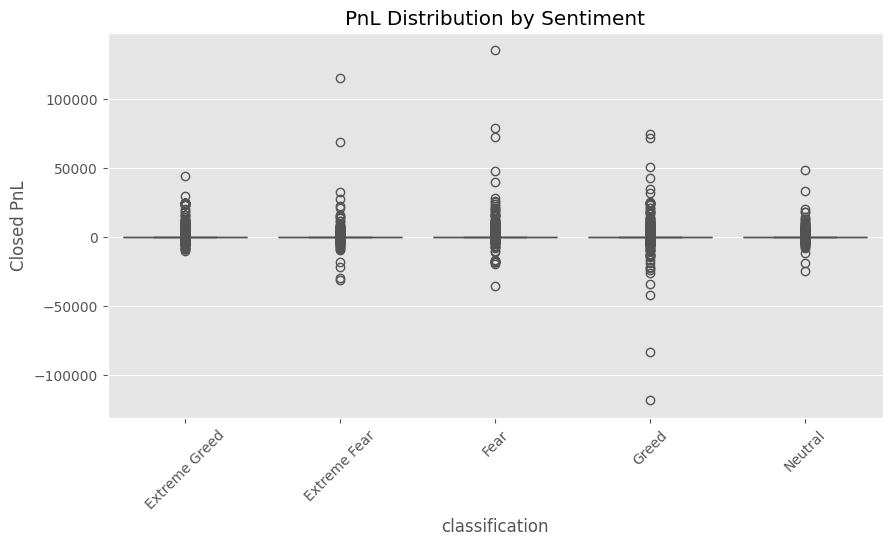

In [ ]:
plt.figure(figsize=(10,5))
sns.boxplot(x='classification', y='Closed PnL', data=df)
plt.xticks(rotation=45)
plt.title("PnL Distribution by Sentiment")
plt.show()

Trade Size by **Sentiment**

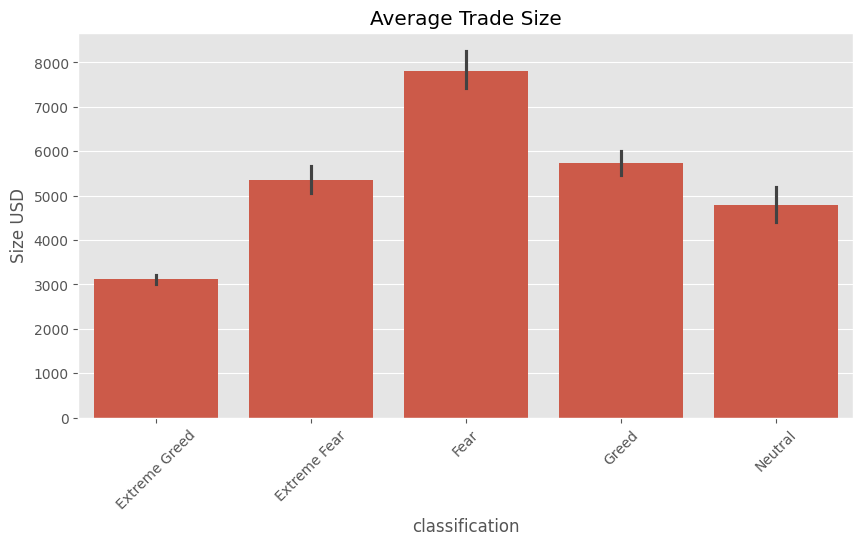

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x='classification', y='Size USD', data=df)
plt.xticks(rotation=45)
plt.title("Average Trade Size")
plt.show()

# Buy/Sell **Ratio**


In [ ]:
pd.crosstab(df['classification'], df['Side'], normalize='index')

Side,BUY,SELL
classification,,
Extreme Fear,0.510981,0.489019
Extreme Greed,0.448590,0.551410
Fear,0.489513,0.510487
Greed,0.488559,0.511441
Neutral,0.503343,0.496657


In [ ]:
volume = df.groupby('Account')['Size USD'].sum()

high_volume = volume[volume > volume.median()]
low_volume = volume[volume <= volume.median()]

print("High Volume Traders:", len(high_volume))
print("Low Volume Traders:", len(low_volume))

High Volume Traders: 16
Low Volume Traders: 16


In [ ]:
profit = df.groupby('Account')['Closed PnL'].sum()

winners = profit[profit > 0]
losers = profit[profit <= 0]

print("Winning Traders:", len(winners))
print("Losing Traders:", len(losers))

Winning Traders: 29
Losing Traders: 3


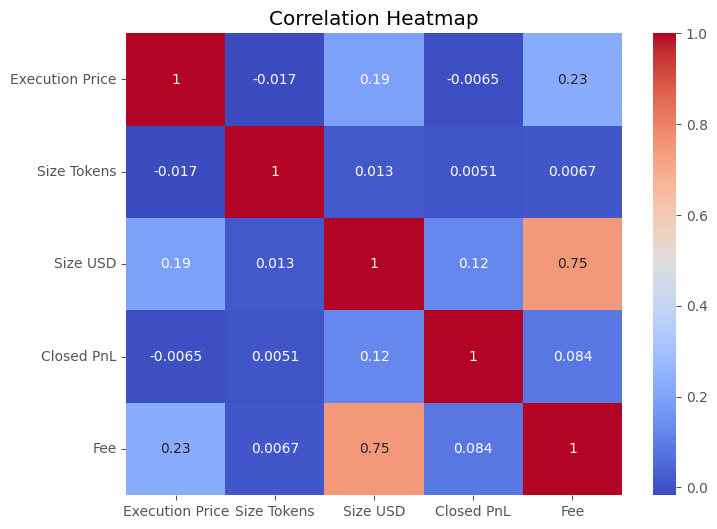

In [ ]:
num = df[['Execution Price','Size Tokens','Size USD','Closed PnL','Fee']]

plt.figure(figsize=(8,6))
sns.heatmap(num.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
print("Project Completed Successfully")
print("Total Traders:", df['Account'].nunique())
print("Total Trades:", len(df))
print("Total Net PnL:", df['Closed PnL'].sum())

Project Completed Successfully
Total Traders: 32
Total Trades: 211224
Total Net PnL: 10296958.943436
